# Factor Construction

This notebook constructs several quantitative equity factors:

- Momentum factor
- Size factor
- Volatility factor

Goal:
Explore whether these factors have predictive power for future stock returns.

In [25]:
import pandas as pd
import numpy as np

print("Quant factor research notebook initialized")

Quant factor research notebook initialized


## Momentum Factor

In [26]:
# Example momentum factor calculation

prices = pd.Series([100, 102, 105, 110, 108])

momentum = prices.pct_change(periods=2)

print(momentum)

0         NaN
1         NaN
2    0.050000
3    0.078431
4    0.028571
dtype: float64


### Interpretation

The momentum factor measures recent price performance.

Positive momentum values indicate upward price trends, while negative values indicate downward trends.

This factor is commonly used in quantitative equity investing because stocks with strong recent performance may continue outperforming in the short term.


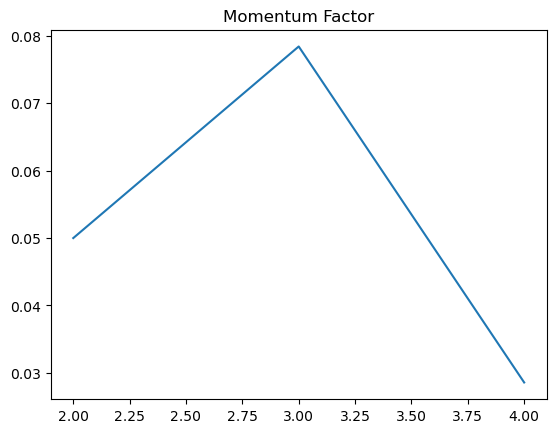

In [27]:
import matplotlib.pyplot as plt

momentum.plot(title="Momentum Factor")
plt.show()

### Short Interpretation

The momentum factor increased initially, indicating strengthening upward price movement. 

Later, the factor declined, suggesting the recent price trend weakened. 

Momentum factors are commonly used to identify stocks with strong recent performance that may continue outperforming in the short term.

In [28]:
import yfinance as yf

# Download Apple stock data
data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,122.982704,128.715401,122.097723,128.105753,112117500
2023-01-04,124.251190,126.512809,122.992553,124.772344,89113600
2023-01-05,122.933548,125.637653,122.677892,125.008335,80962700
2023-01-06,127.456779,128.115596,122.805722,123.907033,87754700
2023-01-09,127.977928,131.183532,127.722273,128.292595,70790800


In [29]:
# Calculate 20-day momentum factor

data["Momentum_20"] = data["Close"].pct_change(20)

data[["Close", "Momentum_20"]].tail()

Price,Close,Momentum_20
Ticker,AAPL,
Date,,
2023-12-22,191.433090,0.019108
2023-12-26,190.889252,0.017177
2023-12-27,190.988129,0.014443
2023-12-28,191.413345,0.022232
2023-12-29,190.375046,0.013582


## Momentum Factor Analysis

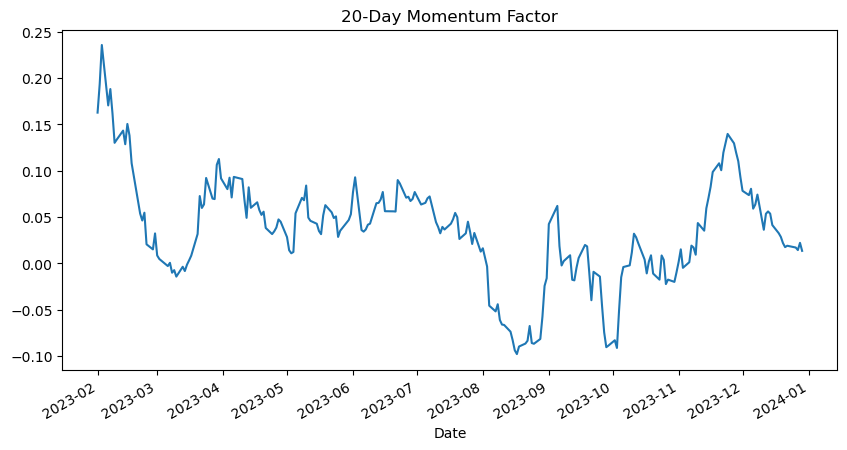

In [30]:
# Plot momentum factor

data["Momentum_20"].plot(
    figsize=(10, 5),
    title="20-Day Momentum Factor"
)

plt.show()

### Interpretation

The 20-day momentum factor shows the recent trend strength of AAPL stock.

Positive values indicate upward momentum, while negative values indicate weakening price performance.

The factor became negative around August–October 2023, suggesting weaker market momentum during that period.

## Momentum Trading Signals

In [31]:
# Generate simple momentum trading signals

data["Signal"] = 0

# Buy signal:
# if momentum > 5%
data.loc[data["Momentum_20"] > 0.05, "Signal"] = 1

# Sell signal:
# if momentum < -5%
data.loc[data["Momentum_20"] < -0.05, "Signal"] = -1

data[["Close", "Momentum_20", "Signal"]].tail(15)

Price,Close,Momentum_20,Signal
Ticker,AAPL,,
Date,,,
2023-12-08,193.519501,0.074326,1
2023-12-11,191.017776,0.036373,0
2023-12-12,192.530655,0.053625,1
2023-12-13,195.744293,0.056125,1
2023-12-14,195.892639,0.053721,1
2023-12-15,195.358658,0.041432,0
2023-12-18,193.697464,0.032685,0
2023-12-19,194.735718,0.028676,0


## Price Chart with Buy Signals

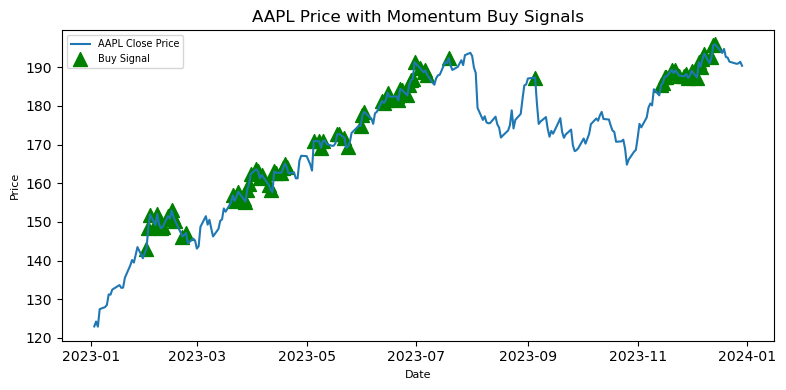

In [32]:
# Plot stock price and buy signals

plt.figure(figsize=(8,4))

# Plot closing price
plt.plot(data.index, data["Close"], label="AAPL Close Price")

# Plot buy signals
buy_signals = data[data["Signal"] == 1]

plt.scatter(
    buy_signals.index,
    buy_signals["Close"],
    color="green",
    label="Buy Signal",
    marker="^",
    s=100
)

plt.title("AAPL Price with Momentum Buy Signals")
plt.xlabel("Date", fontsize=8)
plt.ylabel("Price", fontsize=8)
plt.legend(fontsize=7)
plt.tight_layout()

plt.show()

### Interpretation

The momentum buy signals mostly appeared during upward price trends.

This suggests that positive momentum may help identify bullish market conditions and potential buying opportunities.

## Strategy Returns

In [33]:
# Calculate daily returns

data["Daily_Return"] = data["Close"].pct_change()

# Strategy return:
# use yesterday's signal to avoid look-ahead bias
data["Strategy_Return"] = data["Signal"].shift(1) * data["Daily_Return"]

# Cumulative returns
data["Cumulative_Market"] = (1 + data["Daily_Return"]).cumprod()

data["Cumulative_Strategy"] = (1 + data["Strategy_Return"]).cumprod()

data[[
    "Cumulative_Market",
    "Cumulative_Strategy"
]].tail()

Price,Cumulative_Market,Cumulative_Strategy
Ticker,,
Date,,
2023-12-22,1.556585,0.94739
2023-12-26,1.552163,0.94739
2023-12-27,1.552967,0.94739
2023-12-28,1.556425,0.94739
2023-12-29,1.547982,0.94739


## Cumulative Returns Comparison

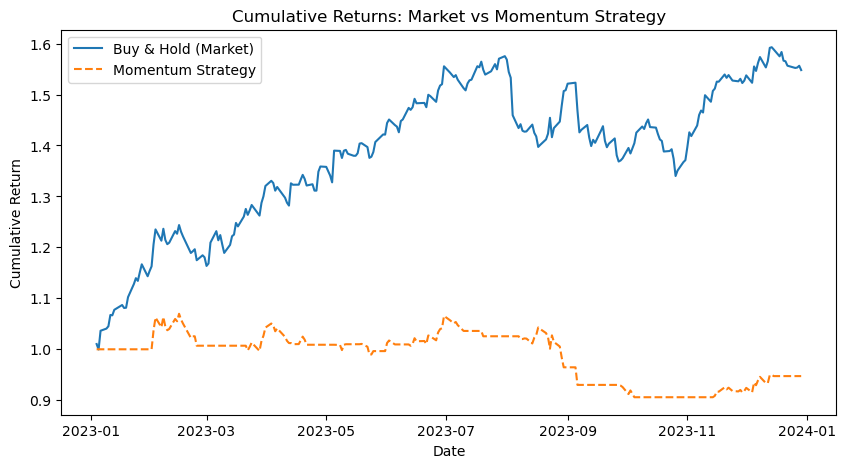

In [34]:
# Plot cumulative returns

plt.figure(figsize=(10,5))

plt.plot(
    data.index,
    data["Cumulative_Market"],
    label="Buy & Hold (Market)"
)

plt.plot(
    data.index,
    data["Cumulative_Strategy"],
    label="Momentum Strategy",
    linestyle="--"
)

plt.title("Cumulative Returns: Market vs Momentum Strategy")

plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.legend()

plt.show()

### Interpretation

The momentum strategy underperformed the buy-and-hold market strategy during this period.

While momentum signals captured some upward trends, the strategy generated lower cumulative returns and experienced periods of decline.

This suggests that the simple momentum signal may require further optimization, additional factors, or better risk management.

## Strategy Risk-Adjusted Performance

In [35]:
# Calculate Sharpe Ratio

strategy_mean = data["Strategy_Return"].mean()

strategy_std = data["Strategy_Return"].std()

sharpe_ratio = (
    strategy_mean / strategy_std
) * np.sqrt(252)

print("Sharpe Ratio:", sharpe_ratio)

Sharpe Ratio: -0.3763516287858671


### Sharpe Ratio Analysis

The momentum strategy produced a negative Sharpe Ratio (-0.38), indicating that the strategy delivered poor risk-adjusted performance during this period.

This suggests that the returns generated by the strategy were not sufficient relative to its volatility and risk exposure.

## Compare Different Momentum Windows

In [36]:
# Test different momentum windows

windows = [5, 10, 20, 60]

for w in windows:
    
    data[f"Momentum_{w}"] = data["Close"].pct_change(w)
    
    print(f"\nMomentum {w}-Day")
    print(data[f"Momentum_{w}"].tail())


Momentum 5-Day
Date
2023-12-22   -0.020094
2023-12-26   -0.014498
2023-12-27   -0.019244
2023-12-28   -0.006416
2023-12-29   -0.011044
Name: Momentum_5, dtype: float64

Momentum 10-Day
Date
2023-12-22   -0.010781
2023-12-26   -0.000673
2023-12-27   -0.008012
2023-12-28   -0.022126
2023-12-29   -0.028166
Name: Momentum_10, dtype: float64

Momentum 20-Day
Date
2023-12-22   NaN
2023-12-26   NaN
2023-12-27   NaN
2023-12-28   NaN
2023-12-29   NaN
Name: Momentum_20, dtype: float64

Momentum 60-Day
Date
2023-12-22    0.135714
2023-12-26    0.129048
2023-12-27    0.113119
2023-12-28    0.124333
2023-12-29    0.110121
Name: Momentum_60, dtype: float64


## Momentum Window Comparison

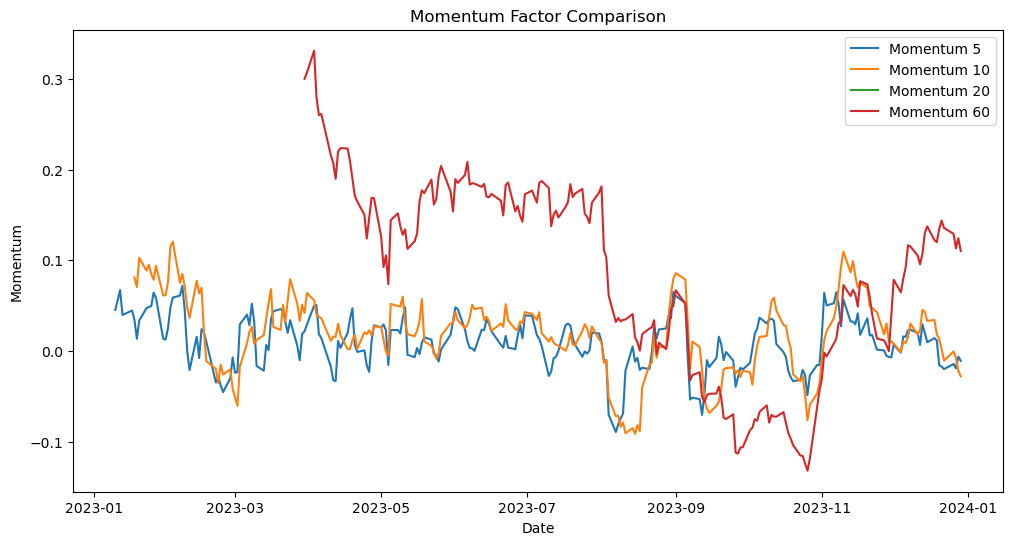

In [37]:
# Plot different momentum windows

plt.figure(figsize=(12,6))

for w in [5, 10, 20, 60]:
    
    plt.plot(
        data.index,
        data[f"Momentum_{w}"],
        label=f"Momentum {w}"
    )

plt.title("Momentum Factor Comparison")

plt.xlabel("Date")
plt.ylabel("Momentum")

plt.legend()

plt.show()

### Momentum Window Comparison

Different momentum windows produce different signal behaviors.

Short-term momentum factors (5-day and 10-day) react more quickly to recent price movements and show higher short-term fluctuations.

Longer-term momentum factors (20-day and 60-day) appear smoother and capture broader market trends.

The 60-day momentum factor showed stronger long-term trend persistence but also experienced larger drawdowns during market reversals.

## Information Coefficient (IC) Analysis

In [48]:
# Recalculate momentum factor

# Use AAPL close price directly

close_price = data["Close"]["AAPL"]

# Recalculate momentum factor
data["Momentum_20"] = close_price.pct_change(20)

# Recalculate future returns
data["Future_Return_5D"] = (
    close_price.shift(-5) / close_price - 1
)

data[["Momentum_20", "Future_Return_5D"]].dropna().head()

Price,Momentum_20,Future_Return_5D
Ticker,,
Date,,
2023-02-01,0.162789,0.044626
2023-02-02,0.193574,0.000331
2023-02-03,0.235802,-0.021097
2023-02-06,0.170576,0.015520
2023-02-07,0.188244,-0.007864


In [49]:
ic = data["Momentum_20"].corr(data["Future_Return_5D"])

print("Information Coefficient (IC):", ic)

Information Coefficient (IC): -0.13540426344439466


### IC Interpretation

The Information Coefficient (IC) of the momentum factor was approximately -0.14.

This negative IC suggests that higher momentum values were associated with weaker future returns during this sample period.

The result indicates that the simple momentum factor did not demonstrate strong predictive power for AAPL in 2023 and may require further refinement or additional filters.